# Multi-Stage Training: Guarino -> Van Rossum

Two-stage curriculum approach:
1. **Stage 1 (Guarino loss)**: Coarse feature matching — spike count, firing rate, first/last spike times
2. **Stage 2 (Van Rossum loss)**: Fine-tune spike timing using exponential-kernel spike train distance

The hypothesis is that Guarino loss gets parameters into the right ballpark (correct spike count),
then the Van Rossum distance refines spike timing by directly comparing filtered spike trains.

In [ ]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley, simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
    make_van_rossum_loss_fn,
    VanRossumLossConfig,
    spike_train_from_voltage,
    make_mse_loss_fn,
    MSELossConfig,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 421.3 pA
Detected spikes: 46


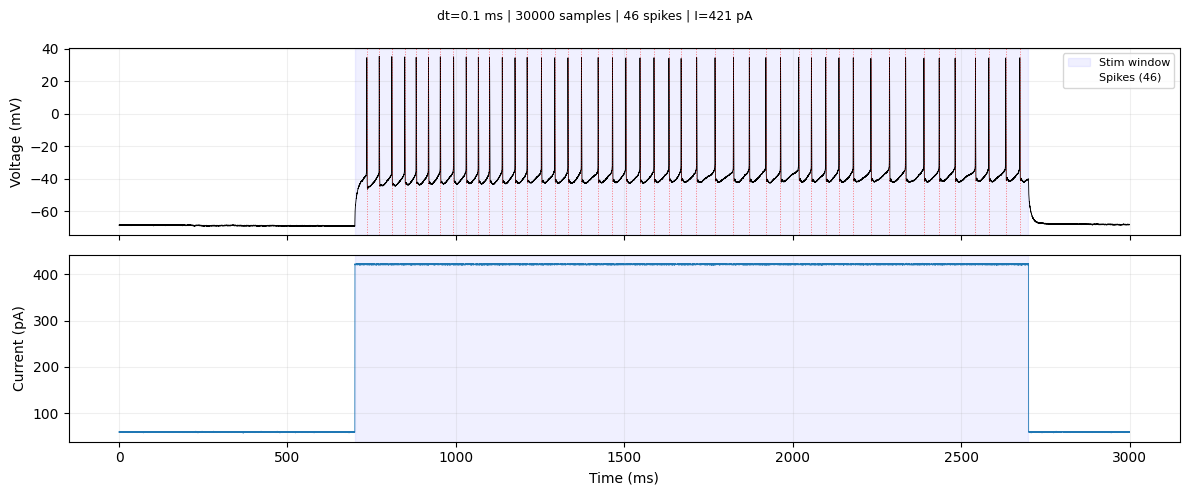

In [38]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)

trace_plot(trace)

print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Cropped trace: 4000 samples, 300.0 ms
Spikes in window: 8 at [135.  172.  209.3 247.6 281.6 318.1 353.3 392.8] ms


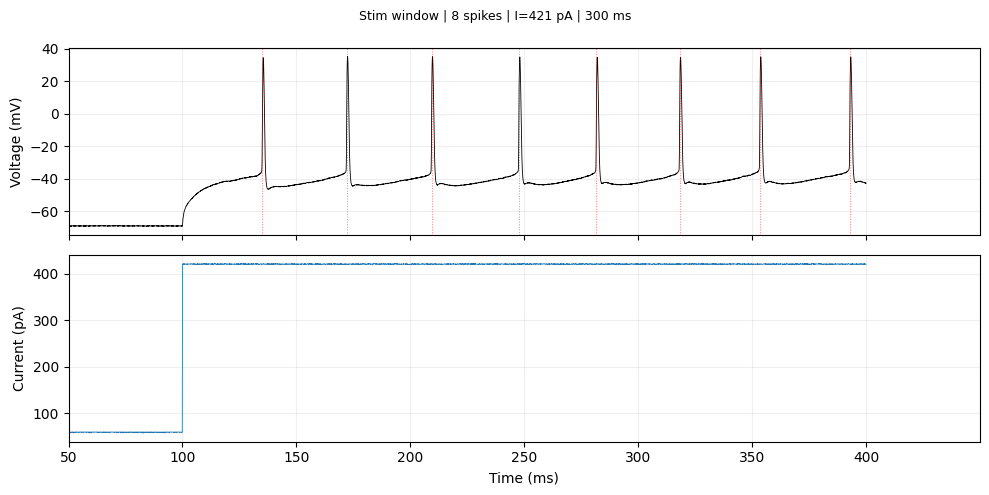

In [39]:
# Crop to stimulation window (500 ms max)
# data = crop_to_stim_window(trace, max_duration_ms=500.0)
data = crop_to_stim_window(
    trace, max_duration_ms=300.0, padding_ms_before=100
)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Initial simulation: 8 spikes, firing rate 20.0 Hz
Experimental:       8 spikes
dt_ms: 0.1
{'C_m': 200.0, 'g_L': 10.0, 'E_L': -75.0, 'v_T': -38.0, 'delta_T': 3.0, 'v_reset': -45.0, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 0.0, 'b': 10.0, 'I': 500.0}


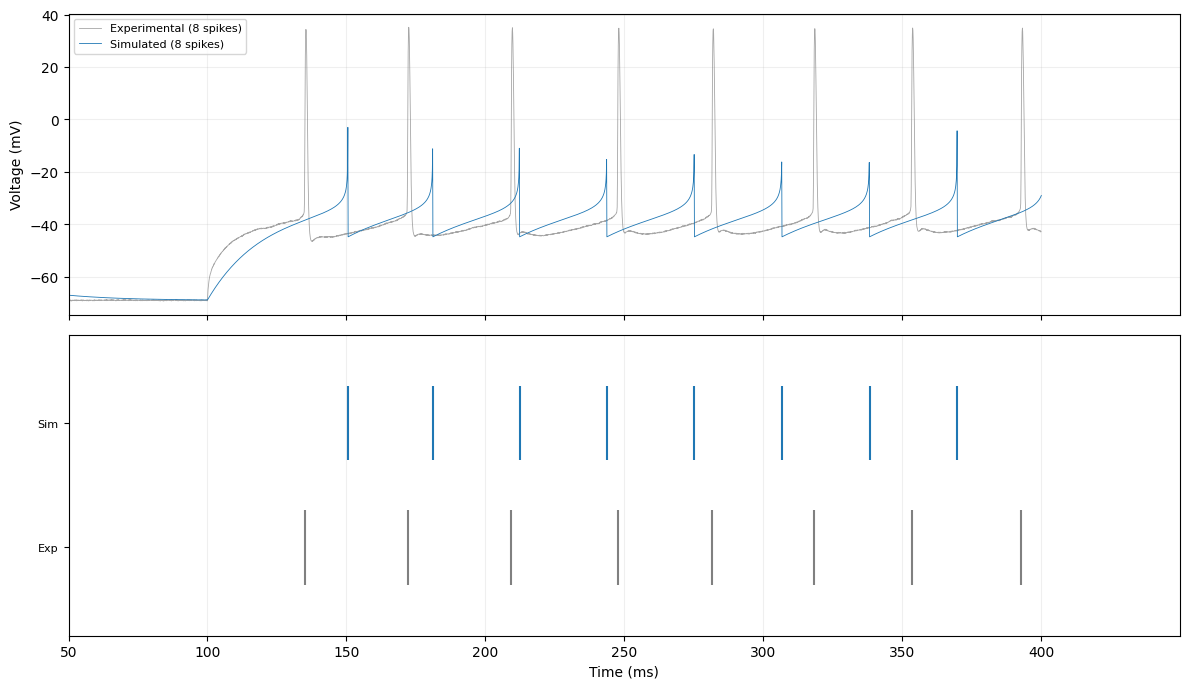

In [40]:
initial_params = dict(NAUD_PARAMETERS["tonic"])
initial_params["v_threshold"] = 0.0
initial_params["v_reset"] = -45.0
initial_params["E_L"] = -75.0
initial_params["v_T"] = -38.0
initial_params["delta_T"] = 3.0 # ToDo: figure out why values > 3.5 make gradients nan

initial_params["a"] = 0.0
initial_params["b"] = 10.0

# sim_init = simulate_jaxley(
#     params=initial_params,
#     stim_current_pA=data.stim_current_pA,
#     stim_duration_ms=data.stim_duration_ms,
#     dt_ms=data.dt_ms,
#     use_surrogate=True,
# )

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init)

print(f"dt_ms: {data.dt_ms}")
print(initial_params)

## 3. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [ ]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_trace_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
exp_voltage = jnp.array(data.voltage)

# --- Stage 1 config: Polyak optimizer, 300 epochs, sigmoid reparameterization ---
config_stage1 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.001,
    n_epochs=100,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=20,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=True,
    use_param_transform=False,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=current_trace_nA,
    dt_ms=data.dt_ms,
    config=config_stage1,
    # Todo: make delta_T trainable (between 2ms up to 20ms)
    trainable_params=["g_L", "tau_w", "v_reset", "v_T", "E_L"]
    # trainable_params=["g_L", "E_L", "v_T", "v_reset", "C_m", "a", "b", "tau_w"],
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn_stage1 = make_guarino_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(
        weight_t_first=25.0,
        weight_t_second=20.0,
        weight_t_third=15.0,
        weight_t_last=10.0,
        weight_firing_freq=10.0,
        weight_spike_count=0.2,
    ),
)

print(f"Initial Guarino loss: {float(loss_fn_stage1(trainable_params1)):.4f}")
print(trainable_params1)

In [ ]:
# ── Alignment diagnostic: verify data, stimuli, and loss function alignment ──
from ADoptEX.plotting import alignment_diagnostic_plot

alignment_diagnostic_plot(data, stim_end_index=data.stim_end_idx);

In [43]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.001 epochs=100 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85
Epoch    0 | loss=5.524521 | grad_norm=6.72e-01 | lr=5.52e-03 | g_L=10.0045, tau_w=30.0000, v_reset=-45.0007, v_T=-37.9980, E_L=-75.0000
Epoch   20 | loss=5.683577 | grad_norm=5.52e+04 | lr=5.68e-03 | g_L=10.0434, tau_w=30.0008, v_reset=-45.0081, v_T=-37.9823, E_L=-74.9921
Epoch   40 | loss=6.858132 | grad_norm=1.48e-01 | lr=6.86e-03 | g_L=10.2674, tau_w=30.0021, v_reset=-45.0404, v_T=-37.8877, E_L=-75.0000
Epoch   60 | loss=9.722625 | grad_norm=1.05e-01 | lr=9.72e-03 | g_L=10.3752, tau_w=30.0028, v_reset=-45.0421, v_T=-37.8522, E_L=-75.0000
Epoch   80 | loss=9.857144 | grad_norm=8.24e-02 | lr=9.86e-03 | g_L=10.4095, tau_w=30.0031, v_reset=-45.0487, v_T=-37.8591, E_L=-74.9974
Training complete: final_loss=9.498086 best_loss=5.492254 (epoch 1) total_time=46.6s mean_epoch=466.1ms lr=5.52e-03->9.50e-03 [returning best]



Stage 1 complete.
  Best loss:   5.4923
  Total time:  46.6 s


In [ ]:
# Evaluate stage 1: simulate and check spike count + Gamma
trained_s1 = result_stage1.get_params_dict()
params_after_s1 = dict(initial_params)
params_after_s1.update(trained_s1)

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);

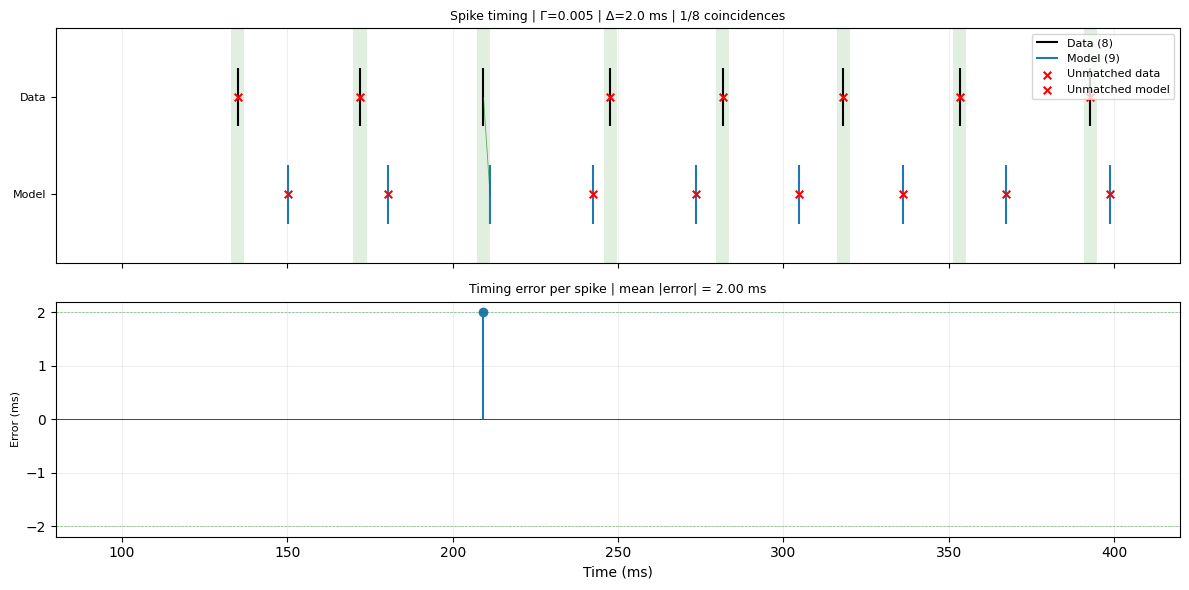

In [45]:
if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);

## 4. Stage 2 — Fine-Tuning

In [ ]:
# Stage 2 starts from stage 1's trained parameters
stage2_params = dict(initial_params)
stage2_params.update(result_stage1.get_params_dict())


print("Stage 2 initial parameters (from stage 1):")
for k, v in result_stage1.get_params_dict().items():
    init_v = initial_params.get(k, float("nan"))
    print(f"  {k:<12} {init_v:>10.3f} -> {v:>10.3f}")

# --- Stage 2 config: Polyak optimizer, sigmoid reparameterization ---
config_stage2 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=20,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
)

# Re-create cell for stage 2 (loss fn closure captures the cell)
cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=stage2_params,
    current_trace_nA=current_trace_nA,
    dt_ms=data.dt_ms,
    config=config_stage2,
    trainable_params=["a", "b", "tau_w"],
)

# Extract target features for Guarino loss (stage 2)
exp_features_s2 = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn_stage2 = make_guarino_loss_fn(
    cell=cell2,
    data_stimuli=data_stimuli2,
    t_max=t_max2,
    dt_ms=data.dt_ms,
    exp_features=exp_features_s2,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(
        weight_t_first=25.0,
        weight_t_second=20.0,
        weight_t_third=15.0,
        weight_t_last=10.0,
        weight_firing_freq=10.0,
        weight_spike_count=0.2,
    ),
)

print(f"\nInitial Stage 2 loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

In [47]:
result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=stage2_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=50 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=9.879309 | grad_norm=4.41e+04 | lr=4.94e-02 | a=-0.6003, b=9.7992, tau_w=29.9151
Epoch   20 | loss=46.453712 | grad_norm=3.20e-01 | lr=2.32e-01 | a=2.6861, b=12.5835, tau_w=43.3271
Epoch   40 | loss=41.904728 | grad_norm=8.27e+00 | lr=2.10e-01 | a=2.7457, b=12.5267, tau_w=108.9848
Training complete: final_loss=32.097519 best_loss=9.879309 (epoch 0) total_time=27.2s mean_epoch=544.5ms lr=4.94e-02->1.60e-01 [returning best]



Stage 2 complete.
  Best loss:   9.8793
  Total time:  27.2 s


## 5. Results

In [ ]:
# Final simulation with stage 2 parameters
trained_s2 = result_stage2.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_s1)
params_final.update(trained_s2)

sim_final = simulate_with_current_trace(
    params=params_final,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Final simulation: {sim_final.n_spikes} spikes (target: {data.n_spikes})")

if sim_final.n_spikes > 0 and data.n_spikes > 0:
    cf_final = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_final.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Coincidence factor Gamma = {cf_final.gamma:.3f} (target > 0.5)")
else:
    cf_final = None
    print("Coincidence factor: N/A (no spikes)")

# Compare with stage 1
if cf_s1 is not None:
    gamma_s2 = f"{cf_final.gamma:.3f}" if cf_final else "N/A"
    print(f"\nStage 1 Gamma: {cf_s1.gamma:.3f} -> Stage 2 Gamma: {gamma_s2}")

print(result_stage2.get_params_dict())

In [49]:
# Show trained parameter values
print("Parameter progression: initial -> stage 1 -> stage 2")
print(
    f"{'Parameter':<12} {'Initial':>10} {'Stage 1':>10} {'Stage 2':>10} {'Bounds':>20}"
)
print("-" * 65)
for k in trained_s2:
    init_v = initial_params.get(k, float("nan"))
    s1_v = trained_s1.get(k, float("nan"))
    s2_v = trained_s2[k]
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {s1_v:>10.3f} {s2_v:>10.3f} {bounds_str:>20}")

Parameter progression: initial -> stage 1 -> stage 2
Parameter       Initial    Stage 1    Stage 2               Bounds
-----------------------------------------------------------------
a                 0.000        nan     -0.600         [-10.0, 3.0]
b                10.000        nan      9.799          [0.0, 65.0]
tau_w            30.000     30.000     29.915        [20.0, 320.0]


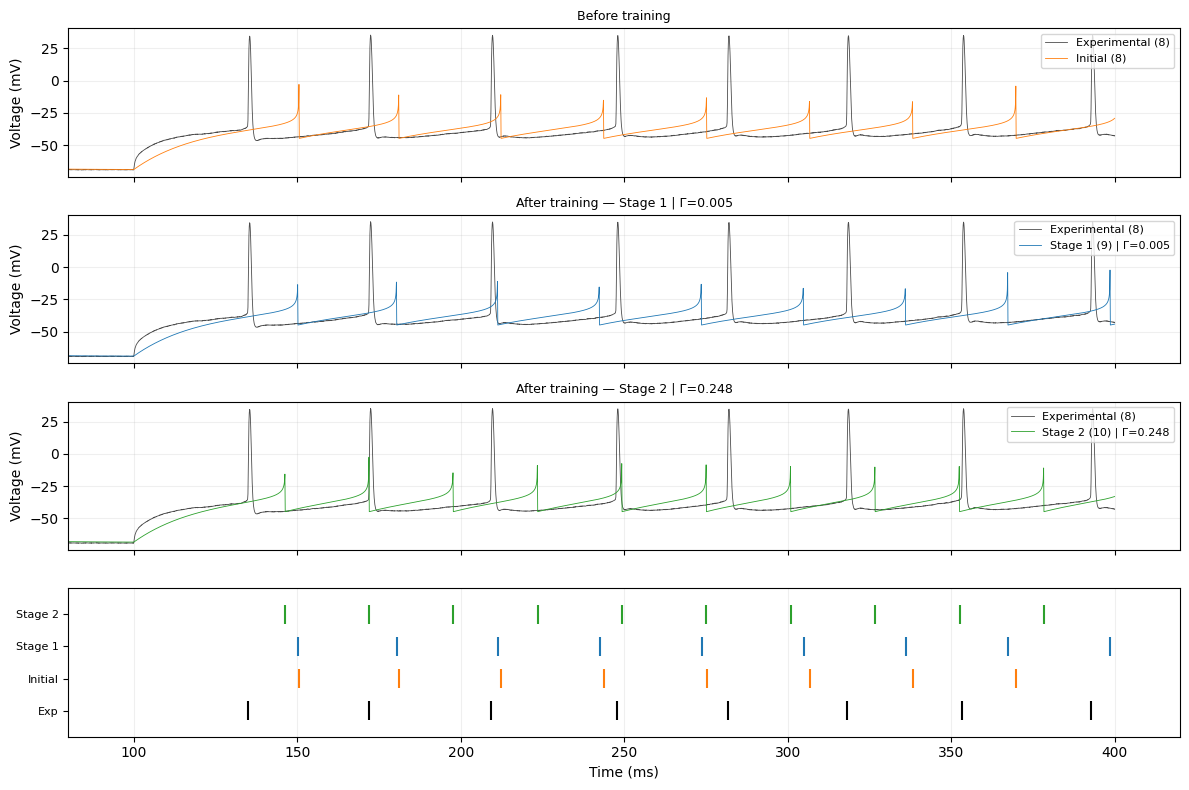

In [50]:
fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1, sim_final],
    coincidence=[cf_s1, cf_final],
    labels=["Stage 1", "Stage 2"],
);

# print(sim_stage1.voltage[1300:1410])

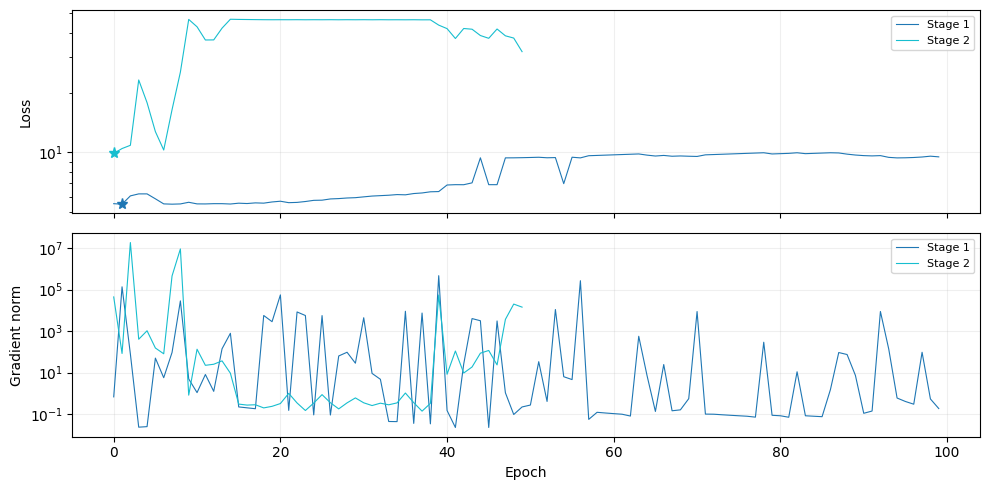

In [51]:
training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1", "Stage 2"],
    show_grad_norms=True,
);

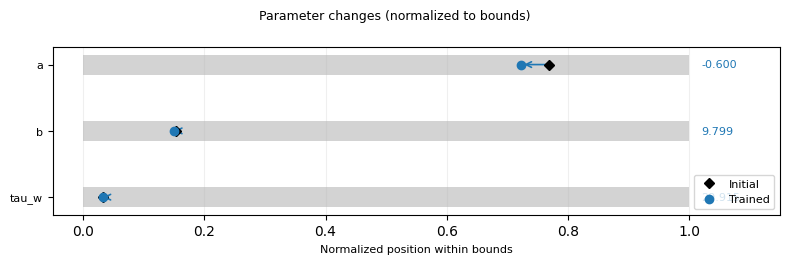

In [52]:
parameter_comparison_plot(result_stage2);

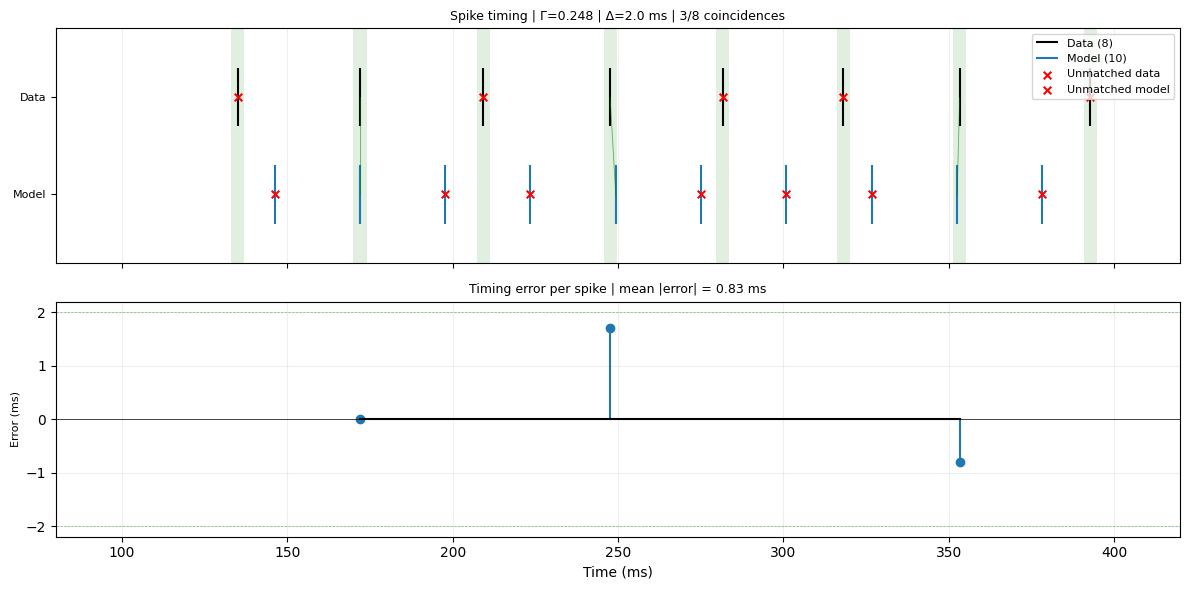

In [53]:
if cf_final is not None:
    spike_timing_plot(data, sim_final, cf_final)
else:
    print("Spike timing plot skipped (no spikes)")